## Process output of simulations

1. Create mean gdfs from simulation runs
2. Create difference gdfs between basecase and policy implementation
3. Create average mode stats
4. Investigate stochasticity of results

In [2]:
import os
import glob
import gzip
import math
import random
import pickle

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
import shapely.wkt as wkt
from shapely.geometry import Point, LineString, box
from shapely.ops import nearest_points
import lxml.etree as ET
import tqdm
import matplotlib.pyplot as plt
import processing_io as pio
import re 

districts = gpd.read_file("../../../../data/visualisation/districts_paris.geojson")

# Parameters to adapt
districts_of_policy_implementation = [5, 6, 7]
is_for_1pm = False
plot_in_percentage = True

string_is_for_1pm = "pop_1pm" if is_for_1pm else "pop_1pct"
string_district_of_interest = "_".join([str(d) for d in districts_of_policy_implementation])

path = "../../../../data/" +  string_is_for_1pm + "_simulations/"
basecase_subdir = pio.get_subdirs(path + string_is_for_1pm + "_basecase/")
comparison_subdir = pio.get_subdirs(path + string_is_for_1pm + "_policy_in_zone_2")

result_path_basecase_mean = "results/" + string_is_for_1pm + "_basecase_average_output_links.geojson"
result_path_comparison_mean = "results/gdf_" + string_is_for_1pm + "_policy_in_" + string_district_of_interest + ".geojson"
result_path_difference = "results/gdf_" + string_is_for_1pm + "_difference.geojson"

compute_comparison_with_basecase = False

In [3]:
random_seed_2_df_basecase_output_links = pio.create_dic_seed_2_output_links(subdir=basecase_subdir)
random_seed_2_df_basecase_trips = pio.create_dic_seed_2_eqasim_trips_given_output_trips(subdir=basecase_subdir)
basecase_output_links_gdfs = list(random_seed_2_df_basecase_output_links.values())
gdf_basecase_mean = pio.compute_average_or_median_geodataframe(geodataframes=basecase_output_links_gdfs, column_name="vol_car", is_mean=True)
gdf_basecase_mean = gdf_basecase_mean.rename(columns={"osm:way:highway": "highway"})
gdf_basecase_mean.to_file(result_path_basecase_mean, driver='GeoJSON')

In [4]:
random_seed_2_df_basecase_trips['{1}']

,person,trip_number,trip_id,dep_time,trav_time,wait_time,traveled_distance,euclidean_distance,main_mode,longest_distance_mode,...,start_facility_id,start_link,start_x,start_y,end_facility_id,end_link,end_x,end_y,first_pt_boarding_stop,last_pt_egress_stop
0,1,1,1_1,09:41:29,00:12:46,00:00:00,920,707,walk,walk,...,home_1,262151,649869.120000,6.860582e+06,sec_409991,515043,649443.100000,6.860017e+06,NaN,NaN
1,1,2,1_2,11:11:29,00:14:24,00:00:00,1370,1038,pt,walk,...,sec_409991,515043,649443.100000,6.860017e+06,sec_229585,537320,649222.230000,6.861031e+06,NaN,NaN
2,10,1,10_1,10:26:16,00:08:21,00:00:00,602,463,walk,walk,...,home_7,43330,656662.136372,6.860692e+06,outside_1,482724,657116.961349,6.860780e+06,NaN,NaN
3,10,2,10_2,15:56:16,00:00:01,00:00:00,1802,1801,outside,outside,...,outside_1,482724,657116.961349,6.860780e+06,outside_2,112845,658918.022379,6.860728e+06,NaN,NaN
4,10,3,10_3,16:01:41,00:02:01,00:00:00,146,111,walk,walk,...,outside_2,112845,658918.022379,6.860728e+06,outside_3,118289,658968.557163,6.860628e+06,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142753,9997623,2,9997623_2,11:20:19,00:05:11,00:00:00,2147,1518,car,car,...,work_2343689,561817,652993.810000,6.859080e+06,outside_26,108473,653508.573590,6.857651e+06,NaN,NaN
142754,9998180,1,9998180_1,07:13:33,00:07:09,00:00:00,3794,2547,car_passenger,car_passenger,...,outside_116,108472,653521.987413,6.857658e+06,edu_11045,581070,651724.100000,6.859464e+06,NaN,NaN
142755,9998180,2,9998180_2,16:45:23,00:28:42,00:00:00,3540,2630,pt,pt,...,edu_11045,581070,651724.100000,6.859464e+06,outside_57,339663,654302.838874,6.858944e+06,NaN,NaN
142756,9998181,1,9998181_1,10:50:30,00:29:14,00:00:00,6152,5457,pt,pt,...,outside_57,339663,654302.838874,6.858944e+06,work_2351574,260151,650788.900000,6.863119e+06,NaN,NaN


In [5]:
# Helper function to convert time strings to total seconds
def convert_time_to_seconds(df, column_name):
    df[column_name] = pd.to_timedelta(df[column_name]).dt.total_seconds()
    return df

# Calculate average travel time, routed distance, and trip count per mode across all seeds
def calculate_avg_mode_stats(single_mode_stats_list: list):
    mode_stats_list = []

    for df in single_mode_stats_list:
        # Convert 'trav_time' to total seconds for aggregation
        df = convert_time_to_seconds(df, 'trav_time')

        # Aggregate travel time, traveled distance, and trip count by main mode
        mode_stats = df.groupby('main_mode').agg({
            'trav_time': 'sum',
            'traveled_distance': 'sum',
            'trip_id': 'count'  # Count trips by counting unique trip_ids
        }).reset_index()
        mode_stats_list.append(mode_stats)

    # Concatenate all mode_stats dataframes
    all_mode_stats = pd.concat(mode_stats_list, ignore_index=True)

    # Calculate the average across all seeds
    average_mode_stats = all_mode_stats.groupby('main_mode').agg({
        'trav_time': 'mean',
        'traveled_distance': 'mean',
        'trip_id': 'mean'  # Calculate average trip count
    }).reset_index()

    # Rename columns for clarity
    average_mode_stats.columns = ['main_mode', 'avg_trav_time_seconds', 'avg_traveled_distance', 'average_trip_count']
    
    return average_mode_stats

df_average_mode_stats = calculate_avg_mode_stats(random_seed_2_df_basecase_trips.values())
df_average_mode_stats.to_csv("results/pop_1pct_basecase_average_mode_stats.csv", index=False)

In [6]:
df_average_mode_stats

,main_mode,avg_trav_time_seconds,avg_traveled_distance,average_trip_count
0,bike,3.203165e+06,9.934483e+06,2980.214286
1,car,1.644894e+07,1.665059e+08,35050.166667
2,car_passenger,3.593220e+06,3.807044e+07,8434.000000
3,outside,1.851514e+04,2.495273e+07,25077.976190
4,pt,6.445410e+07,2.208262e+08,39754.333333
5,walk,2.539061e+07,3.048681e+07,31460.571429


In [7]:
if compute_comparison_with_basecase:
    random_seed_2_df_comparison = pio.create_dic_seed_2_output_links(subdir = comparison_subdir)
    geodataframes_comparison = list(random_seed_2_df_comparison.values())
    gdf_comparison_mean = pio.compute_average_or_median_geodataframe(geodataframes=geodataframes_comparison, column_name="vol_car", is_mean=True)
    gdf_comparison_mean_extended = pio.extend_geodataframe(gdf_base = gdf_basecase_mean, gdf_to_extend=gdf_comparison_mean, column_to_extend='highway', new_column_name='highway')
    gdf_basecase_without_unnecessary_columns = pio.remove_columns(gdf_with_correct_columns=gdf_comparison_mean_extended, gdf_to_be_adapted=gdf_basecase_mean)
    gdf_basecase_difference = pio.compute_difference_geodataframe(gdf_to_substract_from=gdf_comparison_mean_extended, gdf_to_substract=gdf_basecase_without_unnecessary_columns, column_name= 'vol_car')
    gdf_comparison_mean_extended.to_file(result_path_comparison_mean, driver='GeoJSON')
    gdf_basecase_difference.to_file(result_path_difference, driver='GeoJSON')

In [8]:
def calculate_edge_variance_metrics(simulation_gdfs, mean_gdf):
    edge_volumes = {}
    
    # Collect volumes for each edge across all simulations
    for df in simulation_gdfs:
        for idx, row in df.iterrows():
            link = row['link']
            volume = row['vol_car']
            if link not in edge_volumes:
                edge_volumes[link] = []
            edge_volumes[link].append(volume)
    
    # Calculate various variance metrics for each edge
    variances = {}
    cvs = {}  # Coefficient of Variation
    normalized_vars = {}  # Normalized Variance
    
    for link, volumes in edge_volumes.items():
        volumes_array = np.array(volumes)
        mean_vol = np.mean(volumes_array)
        var = np.var(volumes_array)
        std = np.std(volumes_array)
        
        variances[link] = var
        # CV = (standard deviation / mean) * 100%
        cvs[link] = (std / mean_vol * 100) if mean_vol != 0 else 0
        # Normalized variance = variance / mean^2
        normalized_vars[link] = (var / (mean_vol ** 2)) if mean_vol != 0 else 0
    
    # Add metrics to the mean_gdf
    mean_gdf['variance'] = mean_gdf['link'].map(variances)
    mean_gdf['cv_percent'] = mean_gdf['link'].map(cvs)  # Coefficient of Variation as percentage
    mean_gdf['normalized_variance'] = mean_gdf['link'].map(normalized_vars)
    
    return mean_gdf

# Apply the function to add variance metrics
gdf_basecase_mean = calculate_edge_variance_metrics(basecase_output_links_gdfs, gdf_basecase_mean)

In [9]:
# Compute the mean coefficient of variation over all edges
mean_cv_percent = gdf_basecase_mean['cv_percent'].mean()
print(f"\nMean Coefficient of Variation (CV) over all edges: {mean_cv_percent:.2f}%")

# Compute the mean car volume over all edges
mean_car_volume = gdf_basecase_mean['vol_car'].mean()
print(f"\nMean Car Volume over all edges: {mean_car_volume:.2f}")


# Investigate the coefficient of variation for different types of "highway"
highway_types = ['primary', 'secondary', 'tertiary', 'residential', 'trunk', 'living_street']
highway_cv_means = {}
highway_vol_means = {}

for highway in highway_types:
    highway_gdf = gdf_basecase_mean[gdf_basecase_mean['highway'] == highway]
    mean_cv = highway_gdf['cv_percent'].mean()
    highway_cv_means[highway] = mean_cv
    print(f"Mean Coefficient of Variation (CV) for {highway} roads: {mean_cv:.2f}%")
    
    mean_vol = highway_gdf['vol_car'].mean()
    highway_vol_means[highway] = mean_vol
    print(f"Mean Car Volume for {highway} roads: {mean_vol:.2f}")



Mean Coefficient of Variation (CV) over all edges: 16.22%

Mean Car Volume over all edges: 50.91
Mean Coefficient of Variation (CV) for primary roads: 8.78%
Mean Car Volume for primary roads: 117.58
Mean Coefficient of Variation (CV) for secondary roads: 13.70%
Mean Car Volume for secondary roads: 51.46
Mean Coefficient of Variation (CV) for tertiary roads: 13.99%
Mean Car Volume for tertiary roads: 35.37
Mean Coefficient of Variation (CV) for residential roads: 25.61%
Mean Car Volume for residential roads: 13.27
Mean Coefficient of Variation (CV) for trunk roads: 0.51%
Mean Car Volume for trunk roads: 1060.73
Mean Coefficient of Variation (CV) for living_street roads: 31.01%
Mean Car Volume for living_street roads: 4.81


In [10]:
# # Create a scatter plot with switched axes
# plt.figure(figsize=(10, 6))
# plt.scatter(list(highway_cv_means.values()), list(highway_vol_means.values()), color='blue')

# # Add labels and title with switched axes
# plt.xlabel('Mean Coefficient of Variation (CV) %')
# plt.ylabel('Mean Car Volume')
# plt.title('Mean Coefficient of Variation (CV) % vs Mean Car Volume for Different Highway Types')

# # Add annotations for each highway type with switched axes
# for highway, cv in highway_cv_means.items():
#     vol = highway_vol_means[highway]
#     plt.annotate(highway, (cv, vol), textcoords="offset points", xytext=(0,10), ha='center')

# # Show the plot
# plt.grid(True)
# plt.show()


# Get upper bounds for each metric

We find that the variance bounds the MSE, and the standard deviation bounds the RMSE from below.

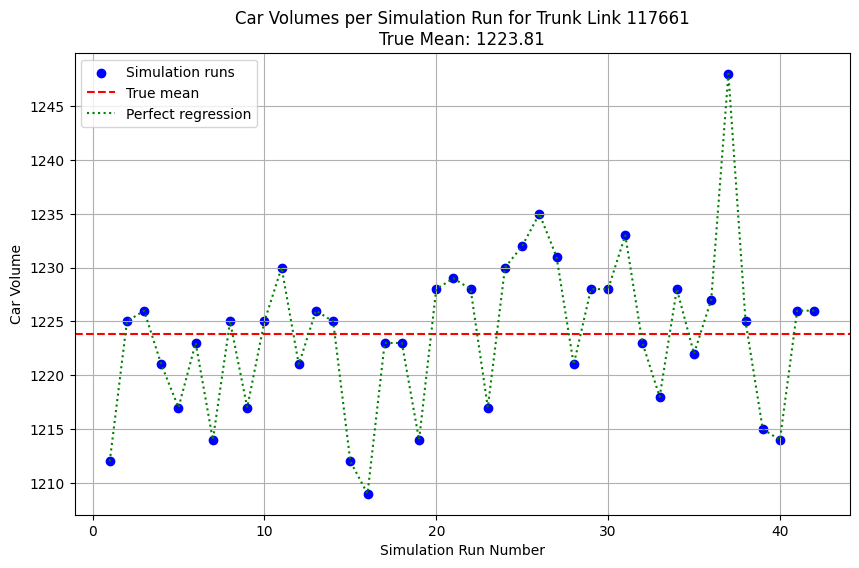

True mean: 1223.81
Number of simulation runs: 42
Standard deviation: 7.25


In [28]:
# Get one trunk link
trunk_link = gdf_basecase_mean[gdf_basecase_mean['highway'] == 'trunk']['link'].iloc[0]

# Get the true mean volume from gdf_basecase_mean
true_mean = gdf_basecase_mean[gdf_basecase_mean['link'] == trunk_link]['vol_car'].iloc[0]

# Get all simulated volumes for this link from different runs
simulated_volumes = []
for df in basecase_output_links_gdfs:
    if trunk_link in df['link'].values:
        volume = df[df['link'] == trunk_link]['vol_car'].iloc[0]
        simulated_volumes.append(volume)

# Create x-axis (simulation run numbers)
run_numbers = range(1, len(simulated_volumes) + 1)

# Create plot
plt.figure(figsize=(10, 6))

# Plot simulated volumes
plt.scatter(run_numbers, simulated_volumes, color='blue', label='Simulation runs')

# Plot mean line
plt.axhline(y=true_mean, color='r', linestyle='--', label='True mean')

# Plot "perfect" regression line (y=x scaled to our data range)
# This would represent perfect correlation between runs
plt.plot(run_numbers, simulated_volumes, color='green', linestyle=':', label='Perfect regression')

plt.xlabel('Simulation Run Number')
plt.ylabel('Car Volume')
plt.title(f'Car Volumes per Simulation Run for Trunk Link {trunk_link}\nTrue Mean: {true_mean:.2f}')
plt.legend()
plt.grid(True)
plt.show()

# Print some statistics
print(f"True mean: {true_mean:.2f}")
print(f"Number of simulation runs: {len(simulated_volumes)}")
print(f"Standard deviation: {np.std(simulated_volumes):.2f}")

In [32]:
# Filter for trunk links
trunk_gdf = gdf_basecase_mean[gdf_basecase_mean['highway'] == 'trunk']
trunk_links = set(trunk_gdf['link'])

print(f"Number of trunk links found: {len(trunk_links)}")

# Lists to store metrics for each link
link_metrics = []

for link in trunk_links:
    # Get true mean for this link
    true_mean = trunk_gdf[trunk_gdf['link'] == link]['vol_car'].iloc[0]
    
    # Get all simulated volumes for this link
    simulated_volumes = []
    for df in basecase_output_links_gdfs:
        if link in df['link'].values:
            volume = df[df['link'] == link]['vol_car'].iloc[0]
            simulated_volumes.append(volume)
    
    # Convert to numpy array
    volumes = np.array(simulated_volumes)
    
    # Calculate metrics
    variance = np.var(volumes)
    std_dev = np.std(volumes)
    cv = (std_dev / true_mean) * 100 if true_mean != 0 else np.nan  # CV as percentage
    mad = np.mean(np.abs(volumes - true_mean))
    
    # Store all metrics for this link
    link_metrics.append({
        'link': link,
        'mean': true_mean,
        'variance': variance,
        'std_dev': std_dev,
        'cv': cv,
        'mad': mad,
        'n_observations': len(volumes)
    })

# Convert to DataFrame for easier analysis
df_metrics = pd.DataFrame(link_metrics)

print("\nSummary statistics:")
print(f"Number of links analyzed: {len(df_metrics)}")
print(f"Average number of observations per link: {df_metrics['n_observations'].mean():.1f}")
print("\nAverages across all trunk links:")
print(f"Average variance: {df_metrics['variance'].mean():.2f}")
print(f"Average standard deviation: {df_metrics['std_dev'].mean():.2f}")
print(f"Average Coefficient of Variation: {df_metrics['cv'].mean():.2f}%")
print(f"Average Mean Absolute Deviation: {df_metrics['mad'].mean():.2f}")

print("\nRanges across links:")
print(f"Mean volumes: {df_metrics['mean'].min():.2f} to {df_metrics['mean'].max():.2f}")
print(f"CV range: {df_metrics['cv'].min():.2f}% to {df_metrics['cv'].max():.2f}%")
print(f"MAD range: {df_metrics['mad'].min():.2f} to {df_metrics['mad'].max():.2f}")

Number of trunk links found: 358

Summary statistics:
Number of links analyzed: 358
Average number of observations per link: 42.0

Averages across all trunk links:
Average variance: 28.14
Average standard deviation: 5.12
Average Coefficient of Variation: 0.52%
Average Mean Absolute Deviation: 4.09

Ranges across links:
Mean volumes: 0.00 to 1596.00
CV range: 0.17% to 10.87%
MAD range: 0.00 to 6.59


In [54]:
# Define road types to analyze
road_types = ['trunk', 'primary', 'secondary', 'tertiary', 'residential', 'living_street']

# Dictionary to store metrics for each road type
road_type_metrics = {}

for road_type in road_types:
    print(f"Analyzing {road_type} roads")
    # Filter for links of this type
    if road_type != 'all':
        type_gdf = gdf_basecase_mean[gdf_basecase_mean['highway'] == road_type]
        links = set(type_gdf['link'])
        
        if len(links) == 0:
            print(f"No links found for type: {road_type}")
            continue
            
    # Lists to store metrics for each link
    link_metrics = []
    
    for link in links:
        if link == 'all':
            true_mean = gdf_basecase_mean['vol_car'].iloc[0]
        else:
            # Get true mean for this link
            true_mean = type_gdf[type_gdf['link'] == link]['vol_car'].iloc[0]
        
        # Get all simulated volumes for this link
        simulated_volumes = []
        for df in basecase_output_links_gdfs:
            if link in df['link'].values:
                volume = df[df['link'] == link]['vol_car'].iloc[0]
                simulated_volumes.append(volume)
        
        # Convert to numpy array
        volumes = np.array(simulated_volumes)
        
        # Calculate metrics
        variance = np.var(volumes)
        std_dev = np.std(volumes)
        cv = (std_dev / true_mean) * 100 if true_mean != 0 else np.nan
        mad = np.mean(np.abs(volumes - true_mean))
        
        link_metrics.append({
            'link': link,
            'mean': true_mean,
            'variance': variance,
            'std_dev': std_dev,
            'cv': cv,
            'mae': mad,
            'n_observations': len(volumes),
        })
    
    # Store metrics for this road type
    road_type_metrics[road_type] = pd.DataFrame(link_metrics)

Analyzing all roads


KeyboardInterrupt: 

In [53]:
for road_type in road_type_metrics:
    print(f"\nSummary for {road_type} roads ({len(road_type_metrics[road_type]['link'])} links):")
    print(f"Average number of observations per link: {road_type_metrics[road_type]['n_observations'].mean():.1f}")
    print(f"Average CV: {road_type_metrics[road_type]['cv'].mean():.2f}%")
    print(f"Average MAE: {road_type_metrics[road_type]['mae'].mean():.2f}")
    print(f"Average Variance: {road_type_metrics[road_type]['variance'].mean():.2f}")
    print(f"Average Standard Deviation: {road_type_metrics[road_type]['std_dev'].mean():.2f}")


Summary for all roads (732 links):
Average number of observations per link: 42.0
Average CV: 38.80%
Average MAE: 0.59
Average Variance: 1.09
Average Standard Deviation: 0.72


In [56]:
# Compute the total number of links in the gdf_basecase
total_links = len(gdf_basecase_mean['link'].unique())

# Compute the mean, variance, and standard deviation of car volumes
car_volume_mean = gdf_basecase_mean['vol_car'].mean()

# Print the results
print(f"Total number of links in the gdf_basecase: {total_links}")
print(f"Car volume mean: {car_volume_mean:.2f}")

Total number of links in the gdf_basecase: 31635
Car volume mean: 50.91
Car volume variance: 18450.31
Car volume standard deviation: 135.83
Corrected car volume variance: 18449.73
